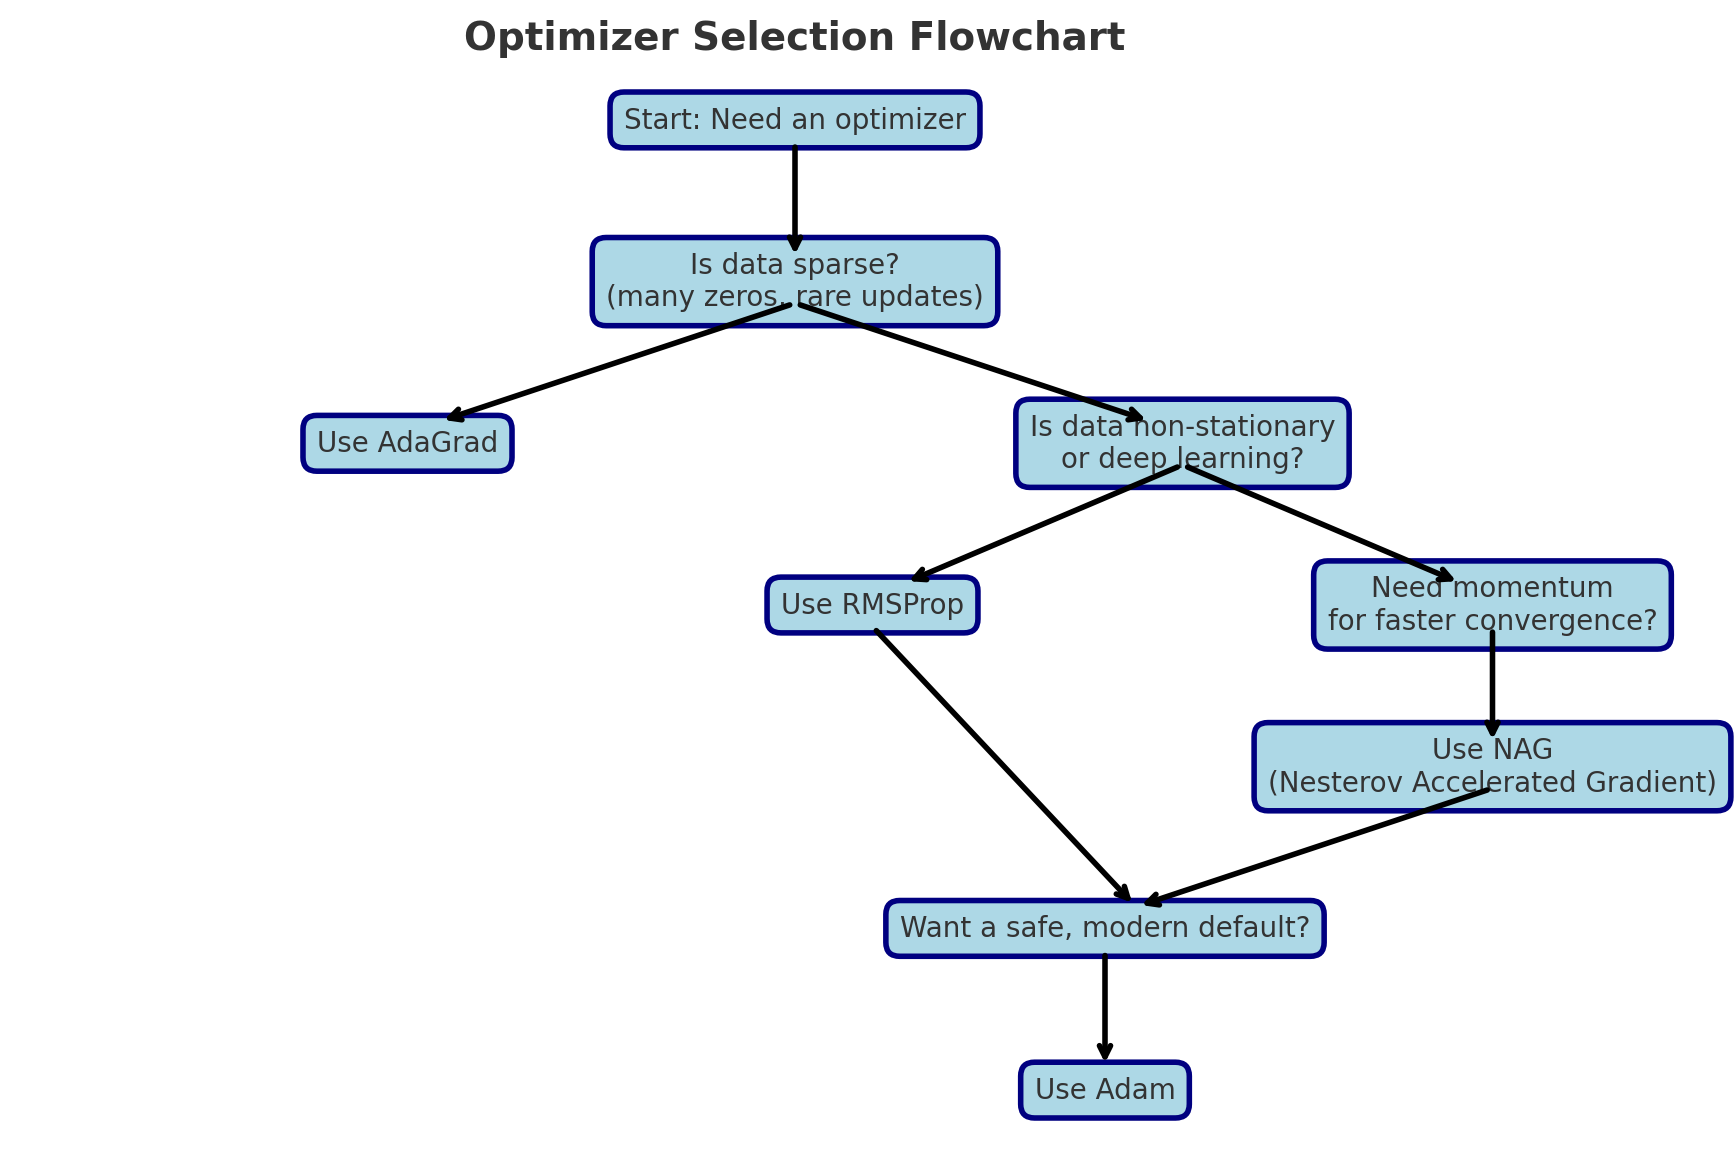



---

## 1. What is RMSProp?

RMSProp is an **optimization algorithm** used to train machine learning models, especially **neural networks**.
It helps the training go faster and more smoothly by **adjusting the learning rate** for each weight based on how the gradient behaves over time.

---

## 2. The problem it solves

If we use **normal gradient descent**, we might have:

* **Too big steps** in some directions → the model jumps around and does not converge.
* **Too small steps** in others → the model learns very slowly.

Also, in some problems, the gradients can change a lot in size. RMSProp tries to keep them stable.

---

## 3. The key idea

Instead of using the gradient directly, RMSProp **divides the learning rate by a moving average of the gradient’s square**.
This means:

* If the gradient is usually large → RMSProp makes the step size smaller.
* If the gradient is usually small → RMSProp makes the step size bigger.

---

## 4. The math step-by-step

Let:

* $g_t$ = gradient at time $t$
* $E[g^2]_t$ = moving average of the squared gradient
* $\rho$ = decay rate (e.g., 0.9)
* $\eta$ = learning rate (e.g., 0.001)
* $\epsilon$ = small number to avoid division by zero

**Step 1:** Update moving average of squared gradient

$$
E[g^2]_t = \rho \cdot E[g^2]_{t-1} + (1 - \rho) \cdot g_t^2
$$

**Step 2:** Update parameter (weight)

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot g_t
$$

---

## 5. Small example

Suppose:

* Current weight: $\theta_t = 0.5$
* Gradient: $g_t = 0.2$
* Decay rate: $\rho = 0.9$
* Learning rate: $\eta = 0.01$
* Previous moving average: $E[g^2]_{t-1} = 0.04$
* $\epsilon = 10^{-8}$

**Step 1:**

$$
E[g^2]_t = 0.9 \cdot 0.04 + 0.1 \cdot (0.2)^2  
= 0.036 + 0.004  
= 0.04
$$

**Step 2:**

$$
\theta_{t+1} = 0.5 - \frac{0.01}{\sqrt{0.04 + 10^{-8}}} \cdot 0.2
$$

$$
\sqrt{0.04} = 0.2
$$

$$
\theta_{t+1} = 0.5 - \frac{0.01}{0.2} \cdot 0.2
$$

$$
\theta_{t+1} = 0.5 - 0.01 = 0.49
$$

---

## 6. Why it works well

* It adapts learning rate separately for each parameter.
* Works better than plain gradient descent for deep networks.
* Handles noisy gradients (e.g., in mini-batch training).

---



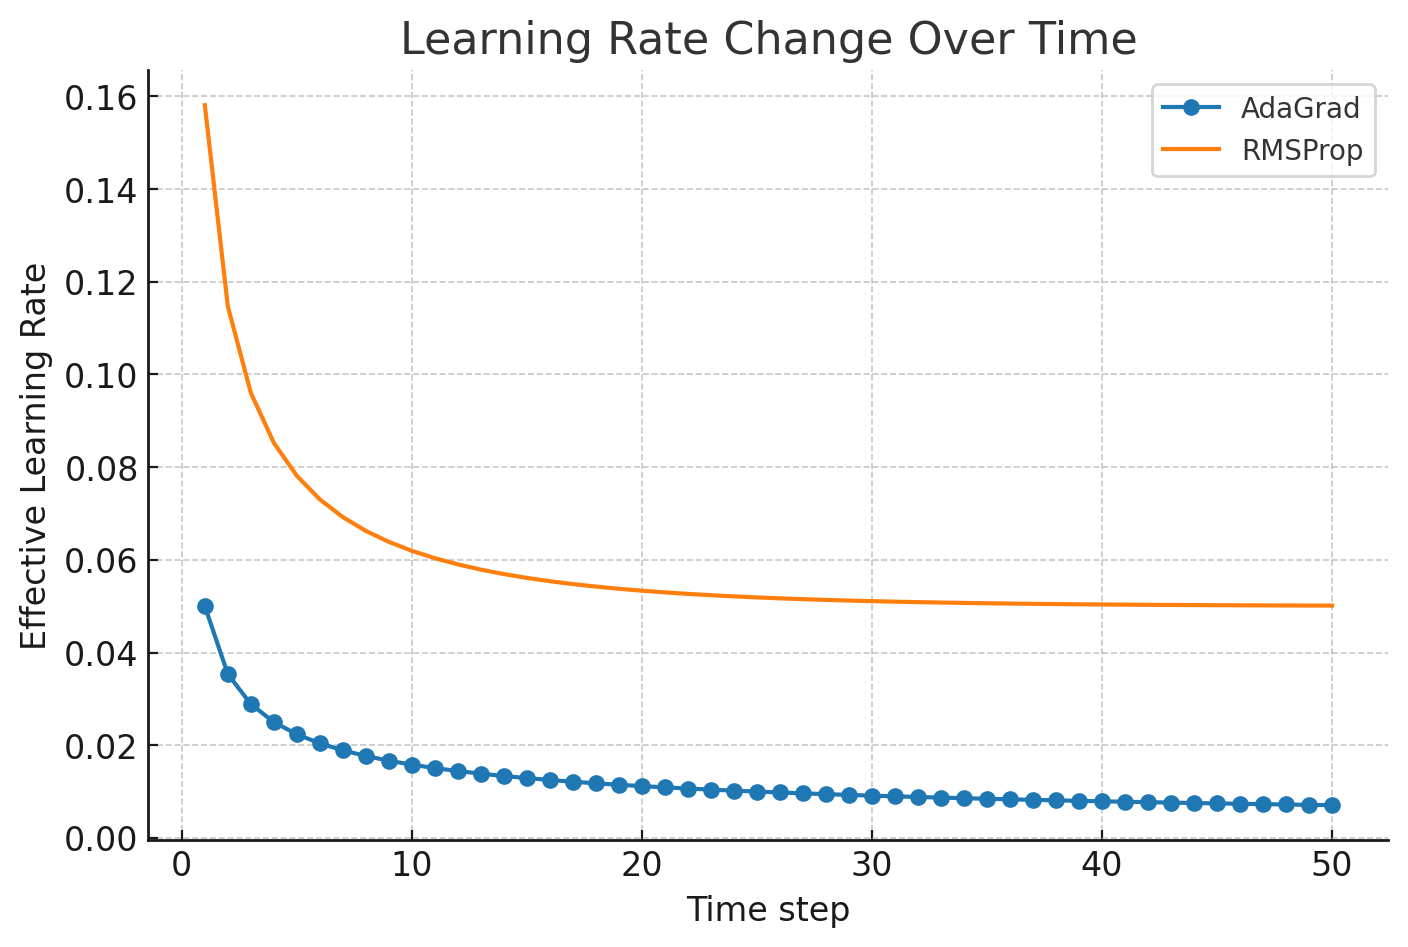


---

## 1. Both have the same goal

AdaGrad and RMSProp both try to **adapt the learning rate** for each parameter based on the history of gradients.
This helps the training avoid **overshooting** in steep directions and **speed up** in flatter ones.

---

## 2. AdaGrad refresher

**AdaGrad** formula:

1. Accumulate sum of squared gradients:

$$
G_t = G_{t-1} + g_t^2
$$

2. Update weights:

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} \cdot g_t
$$

**Key feature:**

* $G_t$ **only grows** (never decreases) because we keep adding squared gradients.
* This means learning rate **keeps getting smaller** over time, and can become **too small** for long training.

---

## 3. RMSProp refresher

**RMSProp** formula:

1. Exponentially decaying average of squared gradients:

$$
E[g^2]_t = \rho \cdot E[g^2]_{t-1} + (1 - \rho) \cdot g_t^2
$$

2. Update weights:

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} \cdot g_t
$$

**Key feature:**

* $E[g^2]_t$ is a **moving average**, not a forever-growing sum.
* This means learning rate **does not shrink forever** — it adjusts based on recent gradient sizes.

---

## 4. Big difference in practice

| Feature                  | AdaGrad                                                             | RMSProp                                         |
| ------------------------ | ------------------------------------------------------------------- | ----------------------------------------------- |
| **Learning rate change** | Shrinks over time, can become too small                             | Adapts to recent gradient history, stays usable |
| **Memory of gradients**  | Remembers *all* past gradients                                      | Remembers *recent* gradients (via decay)        |
| **Good for**             | Sparse data problems (e.g., NLP, where many features rarely update) | Non-stationary problems, deep learning          |
| **Risk**                 | Stops learning too early                                            | Needs decay rate tuning (usually 0.9)           |

---

## 5. Quick numeric illustration

Let’s say:

* Initial $\eta = 0.1$
* Gradient sequence: $g_1 = 2, g_2 = 2, g_3 = 2$
* $\epsilon = 10^{-8}$, decay rate $\rho = 0.9$

**AdaGrad**:

* $G_1 = 4$, effective lr = $0.1 / \sqrt{4} = 0.05$
* $G_2 = 8$, effective lr = $0.1 / \sqrt{8} \approx 0.035$
* $G_3 = 12$, effective lr = $0.1 / \sqrt{12} \approx 0.028$ → keeps shrinking.

**RMSProp**:

* Step 1: $E_1 = 0.1 \cdot 4 = 0.4$, lr ≈ $0.1 / \sqrt{0.4} \approx 0.158$
* Step 2: $E_2 = 0.9 \cdot 0.4 + 0.1 \cdot 4 = 0.76$, lr ≈ $0.1 / \sqrt{0.76} \approx 0.115$
* Step 3: $E_3 = 0.9 \cdot 0.76 + 0.1 \cdot 4 = 1.084$, lr ≈ $0.1 / \sqrt{1.084} \approx 0.096$ → shrinks, but not endlessly.

---






---

## **AdaGrad**

### ✅ When to use:

* **Sparse features**: e.g., text data (NLP), one-hot encodings, recommender systems.
  → It gives *rarely updated parameters* a bigger step size.
* Problems where learning rate naturally should **decrease over time**.

### ❌ Cons:

* Learning rate **shrinks too much** in long training — may stop learning early.
* Not great for **non-stationary problems** (where data distribution changes).
* No way to “forget” old gradients — history can dominate.

---

## **RMSProp**

### ✅ When to use:

* **Deep learning** (especially recurrent neural networks, CNNs).
* **Non-stationary** environments (e.g., reinforcement learning, streaming data).
* When gradients vary a lot during training.
* When you want **stable but adaptable** learning rates.

### ❌ Cons:

* Needs **decay rate ($\rho$) tuning** — usually 0.9, but may need adjusting.
* Less effective in *very sparse* feature spaces compared to AdaGrad.
* Still a bit sensitive to the initial learning rate choice.

---

## 📌 Quick rule of thumb

* If **data is sparse** → try **AdaGrad**.
* If **data is dense and non-stationary** (deep learning) → use **RMSProp**.
* If you want a **modern default** → use **Adam** (it mixes RMSProp + momentum).

---

